In [134]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [135]:
# !unzip train.zip
# !unzip drive/MyDrive/ssne_datasets/trafic_32.zip

In [136]:
# %load_ext autoreload
# %autoreload 2

In [252]:
import os
import json
import math
import numpy as np
import pandas as pd

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import to_rgb
import matplotlib

## PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from torch.optim import Adam

import importlib
from modele import BasicUNet
import vae
import utils
# from utils import train, generate_random_images, save_images, save_model, corrupt

In [253]:

importlib.reload(vae)
importlib.reload(utils)

<module 'utils' from '/content/utils.py'>

In [139]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [140]:
TRAIN_DATA_DIR = "trafic_32"
BATCH_SIZE = 16
OVERFIT_ON_FIRST_BATCH = False

transform = transforms.Compose([transforms.ToTensor()])
dataset = ImageFolder(TRAIN_DATA_DIR, transform=transform)
loader = DataLoader(
    dataset,
    BATCH_SIZE,
    shuffle=not OVERFIT_ON_FIRST_BATCH,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

In [258]:
number_of_classes = 43
all_classes = np.arange(number_of_classes, dtype=int)
class_to_idx = {c: i for i, c in enumerate(all_classes)}

idx = torch.tensor([class_to_idx[x] for x in all_classes])

onehot = nn.functional.one_hot(idx, num_classes=len(all_classes)).to(device)

print(onehot[torch.tensor([0, 1, 2])])

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
       device='cuda:0')


In [142]:
for images, labels in loader:
    print(images.shape)  # [batch_size, 3, 32, 32]
    print(labels.shape)  # [batch_size]
    break

torch.Size([16, 3, 32, 32])
torch.Size([16])


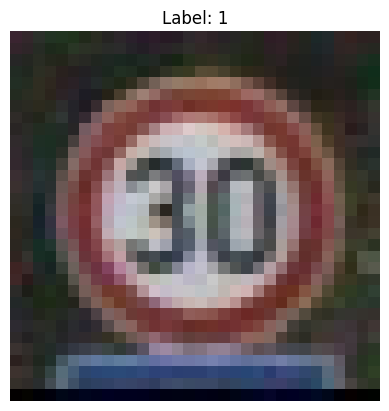

In [280]:
image, label = dataset[500]

plt.imshow(image.permute(1, 2, 0))
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

Input shape: torch.Size([8, 3, 32, 32])


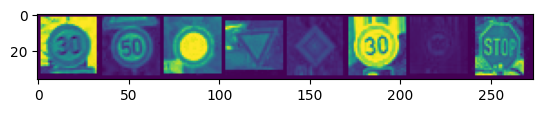

In [273]:
x, y = next(iter(loader))
x = x[:8]
print('Input shape:', x.shape)
plt.imshow(torchvision.utils.make_grid(x)[0]);

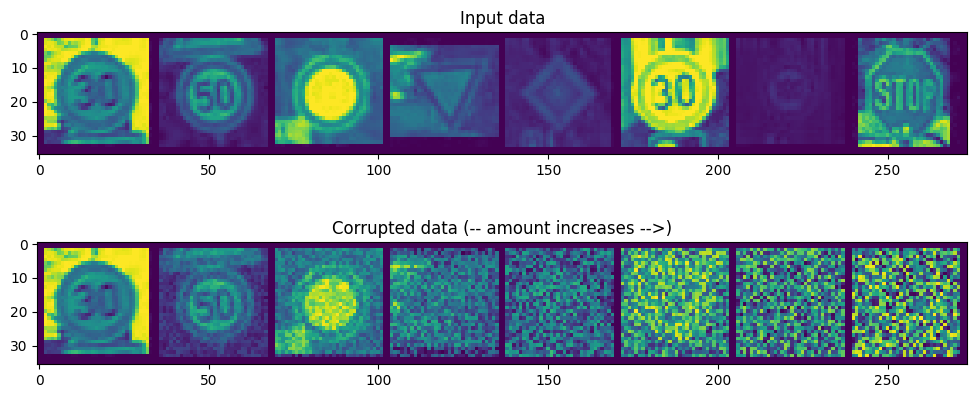

In [274]:
# Plotting the input data
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title('Input data')
axs[0].imshow(torchvision.utils.make_grid(x)[0])

# Adding noise
amount = torch.linspace(0, 1, x.shape[0]) # Left to right -> more corruption
noised_x = corrupt(x, amount)

# Plotting the noised version
axs[1].set_title('Corrupted data (-- amount increases -->)')
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0]);

In [146]:
vae_m = vae.VAE(
    input_dim=3 * 32 * 32,
    hidden_dim=1024,
    latent_dim=128,
    output_dim=3 * 32 * 32,
    condition_size=onehot.shape[0],
).to(device)
optimizer = Adam(vae_m.parameters(), lr=0.0003)
vae_m


VAE(
  (encoder): Encoder(
    (fc1): Linear(in_features=3115, out_features=1024, bias=True)
    (fc2): Linear(in_features=1024, out_features=1024, bias=True)
    (fc_mean): Linear(in_features=1024, out_features=128, bias=True)
    (fc_log_std): Linear(in_features=1024, out_features=128, bias=True)
    (lrelu): LeakyReLU(negative_slope=0.3)
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=171, out_features=1024, bias=True)
    (fc2): Linear(in_features=1024, out_features=1024, bias=True)
    (fc3): Linear(in_features=1024, out_features=3072, bias=True)
    (lrelu): LeakyReLU(negative_slope=0.3)
  )
)

[1/10], Loss: 7.57e+02
[2/10], Loss: 7.51e+02
[3/10], Loss: 7.47e+02
[4/10], Loss: 7.43e+02
[5/10], Loss: 7.41e+02
[6/10], Loss: 7.37e+02
[7/10], Loss: 7.33e+02
[8/10], Loss: 7.31e+02
[9/10], Loss: 7.27e+02
[10/10], Loss: 7.25e+02


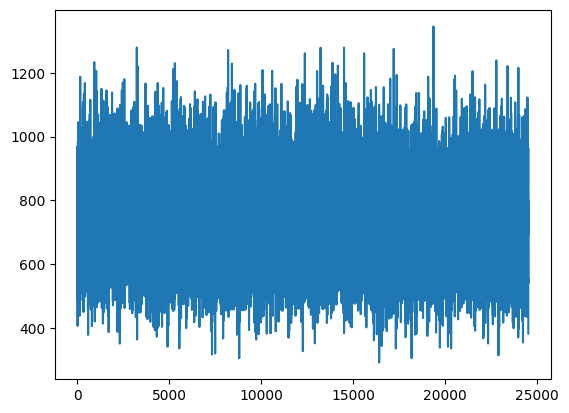

In [270]:
EPOCHS = 10
losses = []

utils.train(
    model=vae_m,
    optimizer=optimizer,
    loader=loader,
    onehot=onehot,
    overfit_on_single_batch=OVERFIT_ON_FIRST_BATCH,
    epochs=EPOCHS,
    show_every=1,
    losses_list=losses,
    device=device,
)

plt.plot(losses)
plt.show()

In [ ]:
save_model(vae, "output/vae_model.pt")

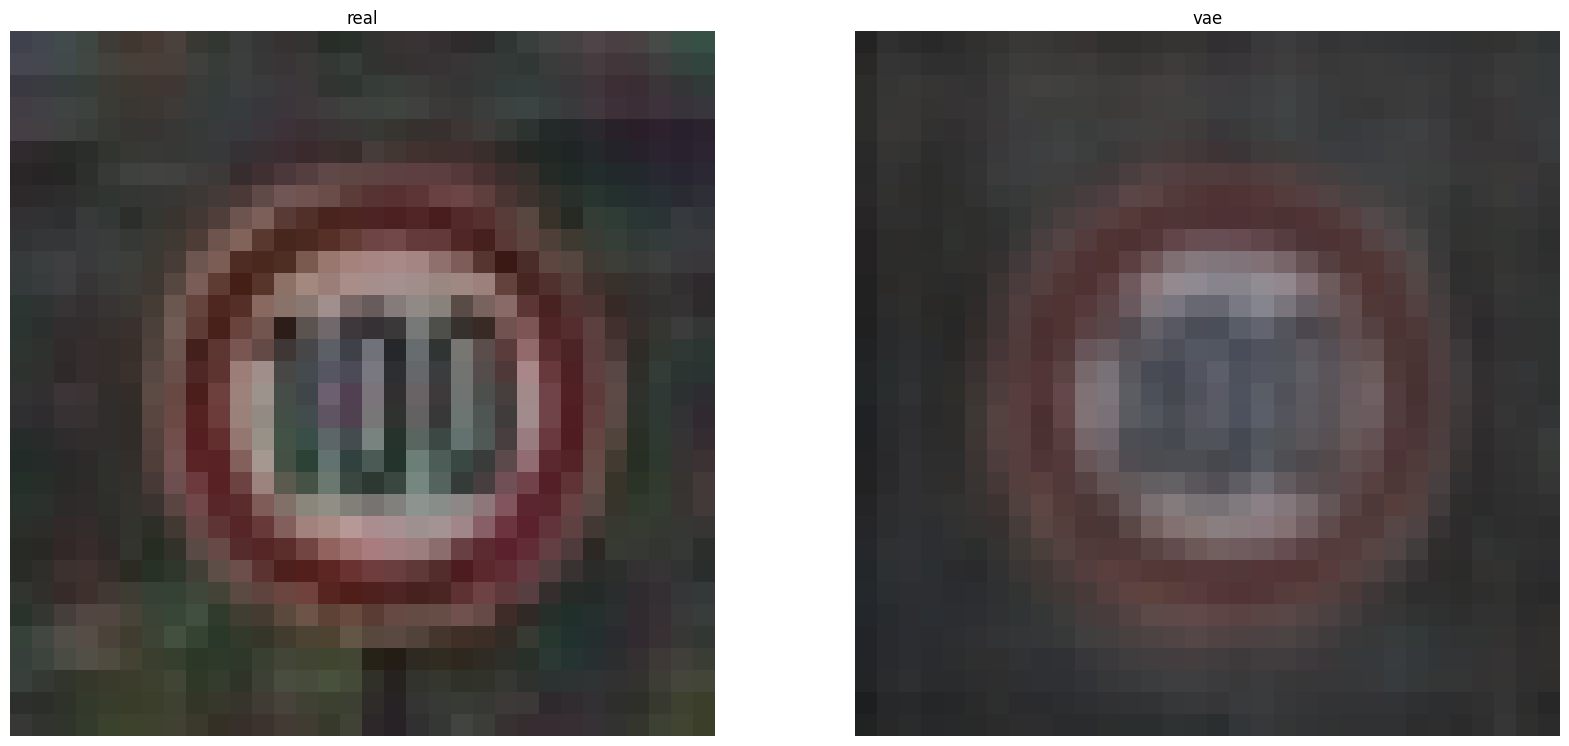

In [271]:
_, axs = plt.subplots(1, 2, figsize=(20, 10))
img, label = next(iter(loader))
recon = vae_m(img.to(device), onehot[label].to(device))[0]
axs[1].axis("off")
axs[1].imshow(recon[0].permute(1, 2, 0).cpu().detach())
axs[1].set_title("vae")
axs[0].imshow(img[0].permute(1, 2, 0).cpu().detach())
axs[0].set_title("real")
axs[0].axis("off")
plt.show()

In [244]:
num_imgs = 1000

In [262]:
import math

targets = np.array(dataset.targets)

# count per class
counts = np.bincount(targets)
total = counts.sum()
dist = []

for c in counts:
  dist.append(c/total)

print(np.array(dist).sum())

y_to_generate = []

i = 0
for d in dist:
  for _ in range(math.ceil(d*num_imgs)):
    y_to_generate.append(i)
  i+=1


diff = len(y_to_generate) - num_imgs
assert diff > 0

x=torch.tensor(y_to_generate, dtype=int).to(device)
perm = torch.randperm(x.size(0))

keep_idx = perm[diff:]   # drop first N shuffled elements
classes = x[keep_idx].to(device)
assert classes.shape[0] == num_imgs

print(classes.shape)
# print((classes == 12).sum())

1.0
torch.Size([1000])


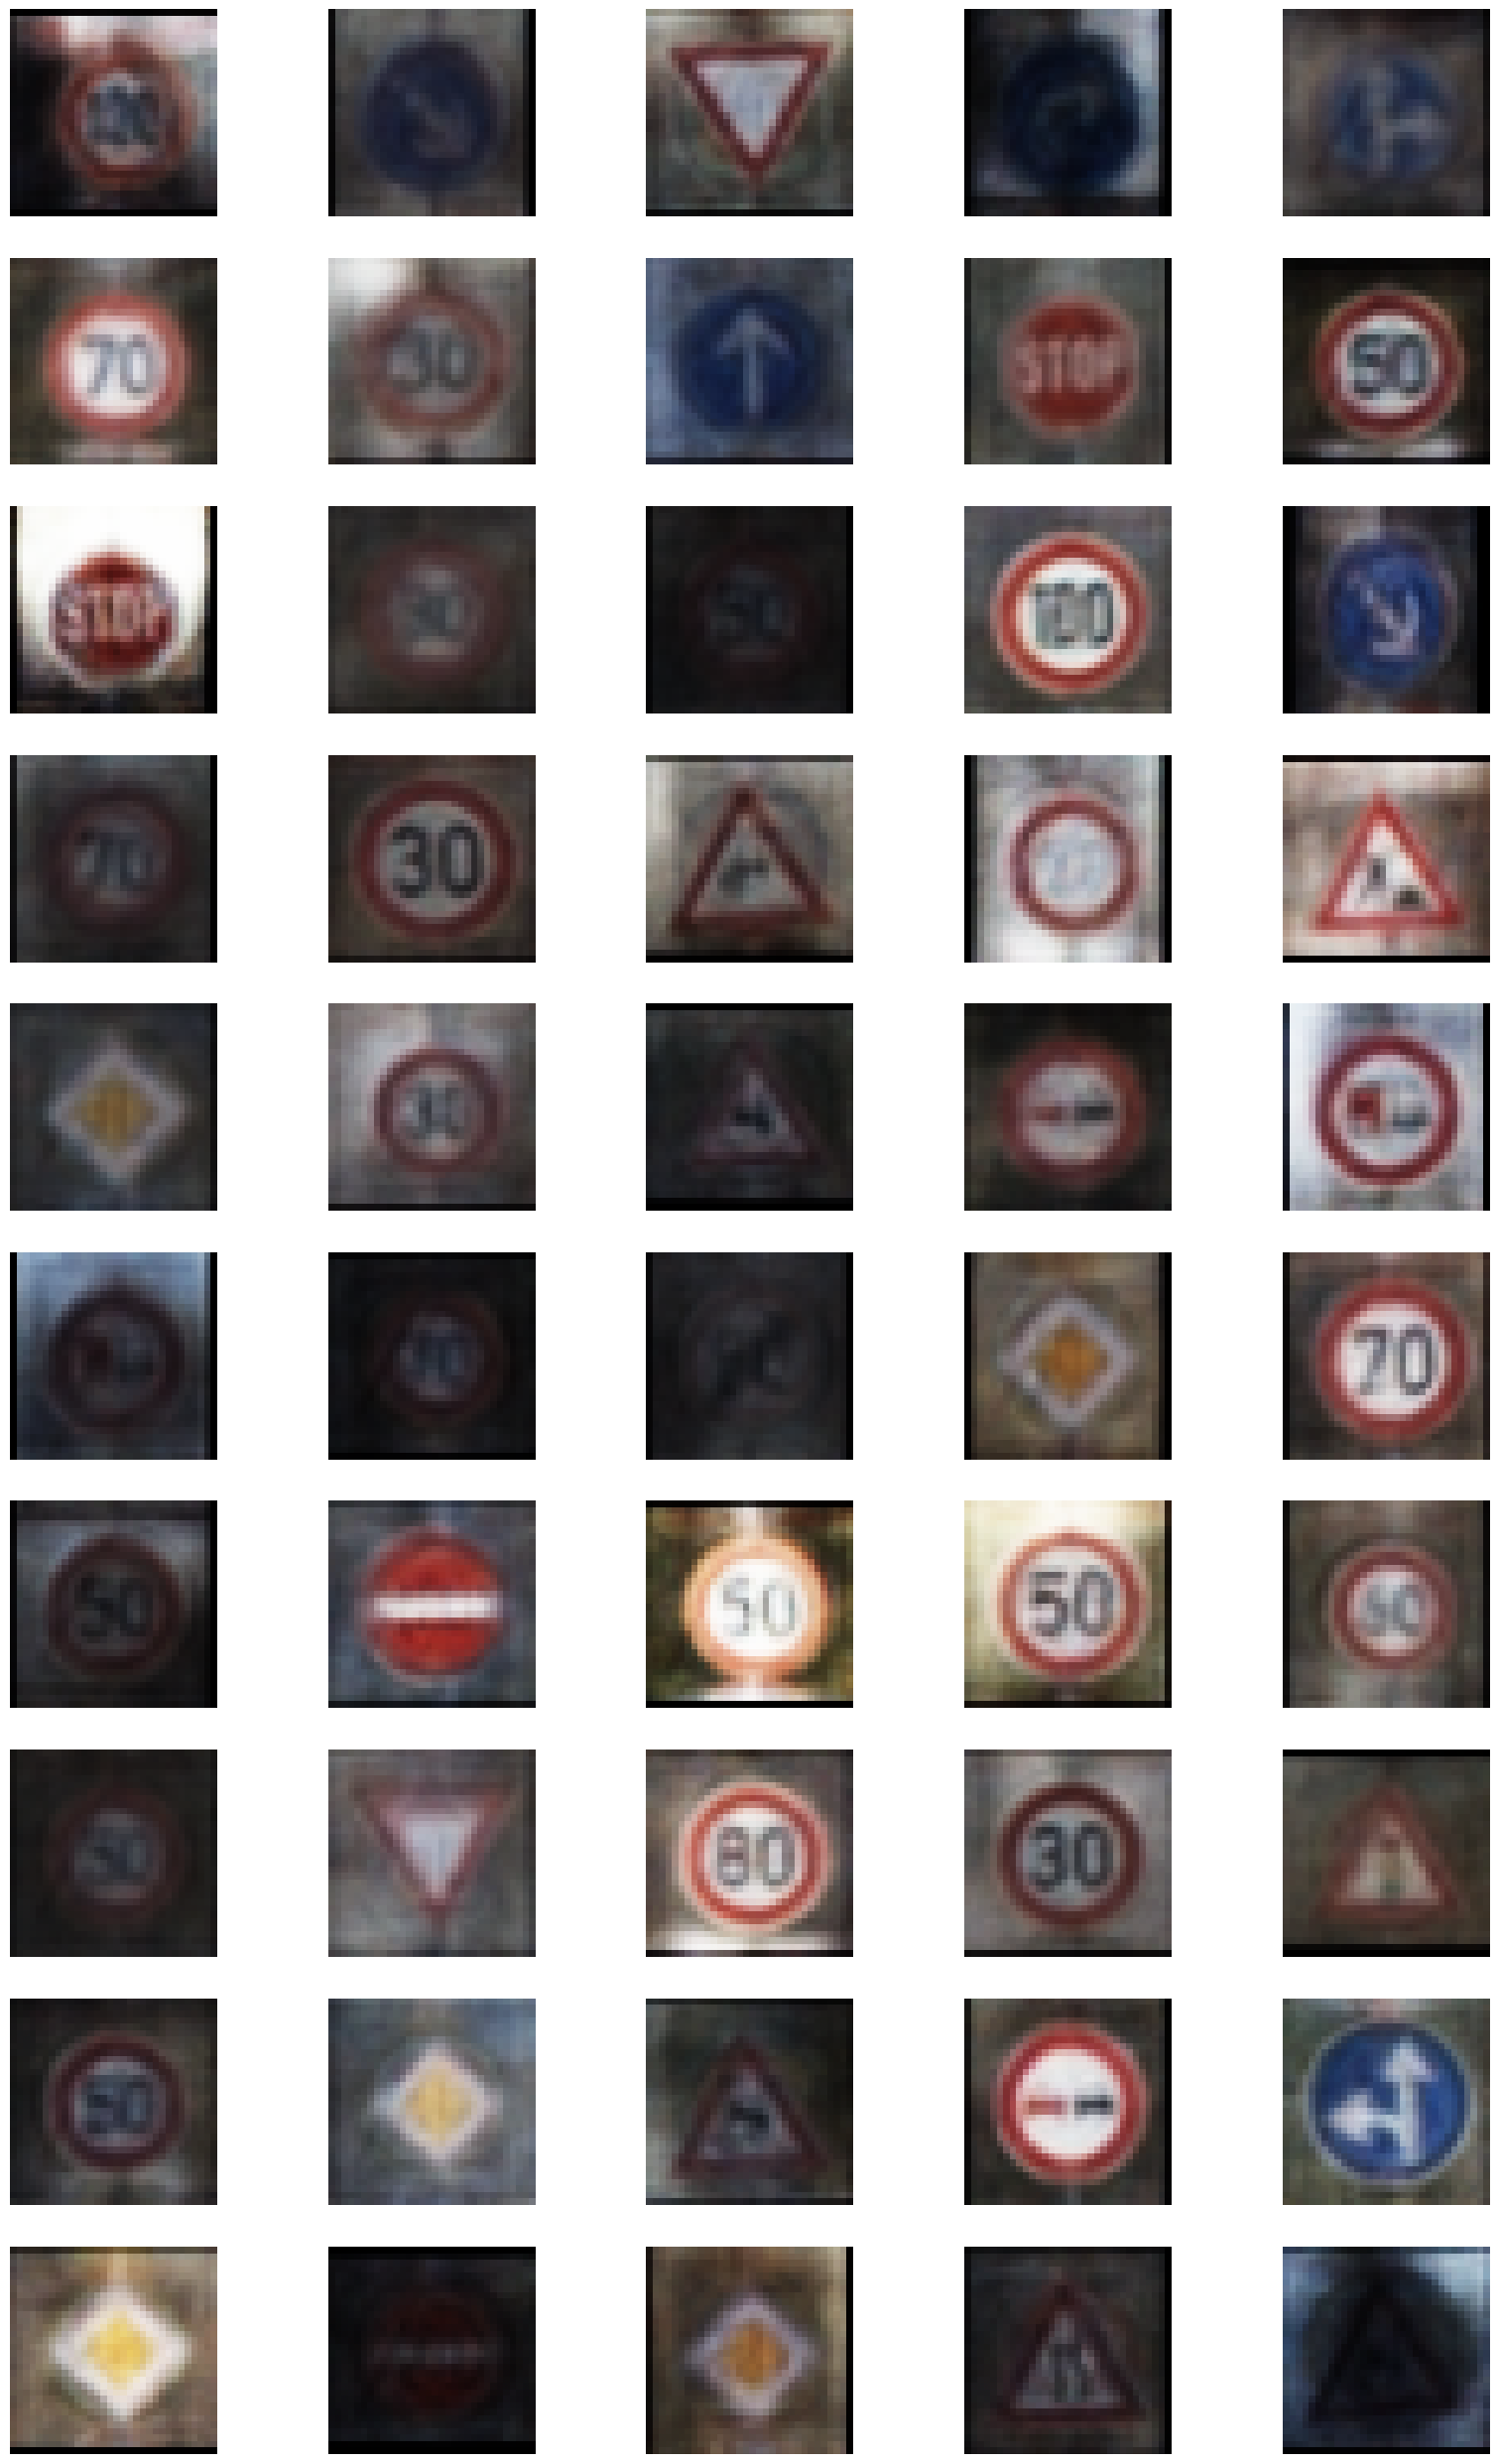

In [272]:
generated_images = utils.generate_random_images(
    model=vae_m,
    onehot=onehot,
    classes=classes,
    num_imgs=num_imgs,
    device=device)
_, axs = plt.subplots(10, 5, figsize=(20, 32))
axs = axs.flatten()
i=0
for a, img in zip(axs, generated_images):
    a.imshow(img.permute(1, 2, 0).cpu().detach())
    a.axis("off")
    i+=1
    if i > 50:
      break
plt.show()

In [269]:
assert generated_images.shape[0] == 1000
utils.save_images(generated_images, "output/generated_vae_FID=45.pt")

In [197]:
import torchvision.models as models
# Pretrained InceptionV3, we use the pool3 layer (2048-d features)
inception = models.inception_v3(pretrained=True, transform_input=False)
inception.fc = torch.nn.Identity()  # remove final classification layer
inception.eval()
inception = inception.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 217MB/s] 


In [204]:
real_features = utils.get_features(loader, inception, device)

In [281]:
class GenDataset(torch.utils.data.Dataset):
    def __init__(self, imgs):
        self.imgs = imgs
    def __len__(self):
        return len(self.imgs)
    def __getitem__(self, idx):
        return self.imgs[idx], 0

print(generated_images.shape)
gen_dataset = GenDataset(generated_images)
gen_loader = torch.utils.data.DataLoader(gen_dataset, batch_size=64)
gen_features = utils.get_features(gen_loader, inception, device)


torch.Size([1000, 3, 32, 32])


In [282]:
print(real_features.shape)
print(gen_features.shape)

(39209, 2048)
(1000, 2048)


In [284]:
fid_score = utils.calculate_frechet_distance(real_features, gen_features)
print("FID:", fid_score)

FID: 44.82818687183493
